# Credit Card Fraud Detection - PCA Encrypted Dataset

**Dataset Overview & Anomaly Detection:**
This dataset contains credit card transactions, and the primary goal is anomaly detection (identifying fraudulent transactions among legitimate ones).
Due to confidentiality and privacy concerns, the dataset is a **PCA (Principal Component Analysis) encrypted dataset**. 
- The original features are not provided.
- Features `V1`, `V2`, ... `V28` are the principal components obtained through the PCA transformation.
- The only features that have not been transformed are `Time` (seconds elapsed between each transaction and the first transaction) and `Amount` (transaction amount).
- The `Class` feature is the target variable, where `1` represents a fraudulent transaction and `0` represents a legitimate transaction.

This severe class imbalance requires specialized handling and evaluation metrics.

# Credit Card Fraud Detection - Poster Visualizations

This notebook generates the key visualizations and statistics used for our project poster.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Data Loading
Loading the credit card dataset.

In [13]:
df = pd.read_csv("../creditcard.csv")

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Basic Statistics
Displaying the basic statistics for the dataset, including the total number of rows and columns.

In [14]:
print("--- BASIC STATISTICS FOR POSTER ---")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"Data Types: Numerical (Floats & Integers)\n")

--- BASIC STATISTICS FOR POSTER ---
Total Rows: 284807
Total Columns: 31
Data Types: Numerical (Floats & Integers)



## 3. Amount Feature Statistics
Calculating detailed statistics for the Amount feature, which is crucial for understanding the transaction values.

In [15]:
amount_mean = df['Amount'].mean()
amount_median = df['Amount'].median()
amount_min = df['Amount'].min()
amount_max = df['Amount'].max()
amount_std = df['Amount'].std()
amount_range = amount_max - amount_min

print("Amount Feature Statistics:")
print(f"Mean: ${amount_mean:.2f}")
print(f"Median: ${amount_median:.2f}")
print(f"Min: ${amount_min:.2f}")
print(f"Max: ${amount_max:.2f}")
print(f"Range: ${amount_range:.2f}")
print(f"Standard Deviation: ${amount_std:.2f}")

Amount Feature Statistics:
Mean: $88.35
Median: $22.00
Min: $0.00
Max: $25691.16
Range: $25691.16
Standard Deviation: $250.12


## 4. Class Imbalance (Bar Chart)
Visualizing the severe class imbalance between genuine and fraudulent transactions using a logarithmic scale.

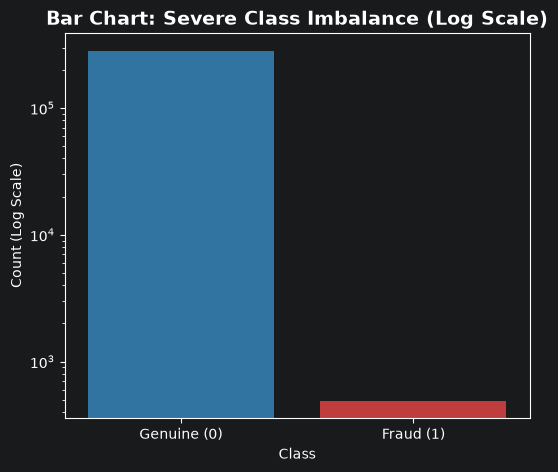

In [16]:
# 1. Bar Chart (Class Imbalance)
plt.figure(figsize=(6, 5))
sns.countplot(x='Class', data=df, hue='Class', palette=['#1f77b4', '#d62728'], legend=False)
plt.title("Bar Chart: Severe Class Imbalance (Log Scale)", fontsize=14, fontweight='bold')
plt.yscale('log')
plt.xticks([0, 1], ['Genuine (0)', 'Fraud (1)'])
plt.ylabel("Count (Log Scale)")
plt.savefig("poster_1_barchart.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Amount Distribution (Histogram)
Visualizing the distribution of transaction amounts, limited to amounts under  for clarity.

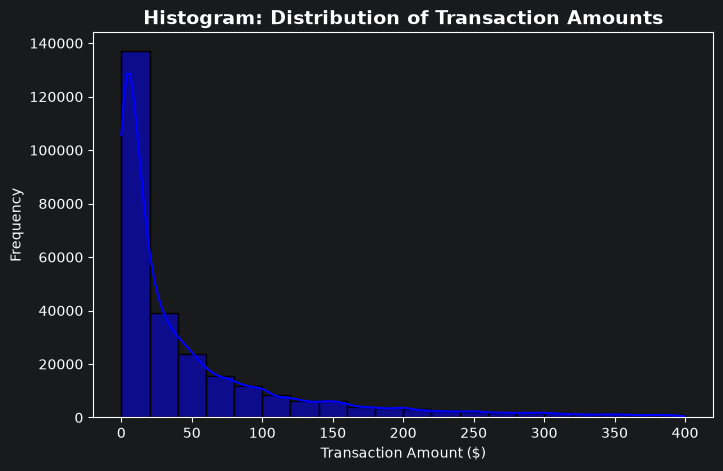

In [17]:
# 2. Histogram (Amount Distribution)
# We limit to amounts < $400 for a cleaner visual, as 99% of data is here
plt.figure(figsize=(8, 5))
sns.histplot(df[df['Amount'] < 400]['Amount'], bins=20, color='blue', kde=True)
plt.title("Histogram: Distribution of Transaction Amounts", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Frequency")
plt.savefig("poster_2_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Outlier Detection (Boxplot)
Using a boxplot with a logarithmic scale to identify outliers in transaction amounts for both genuine and fraud classes.

C:\Users\jsabi\AppData\Local\Temp\ipykernel_23008\3285011078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette=['#1f77b4', '#d62728'])


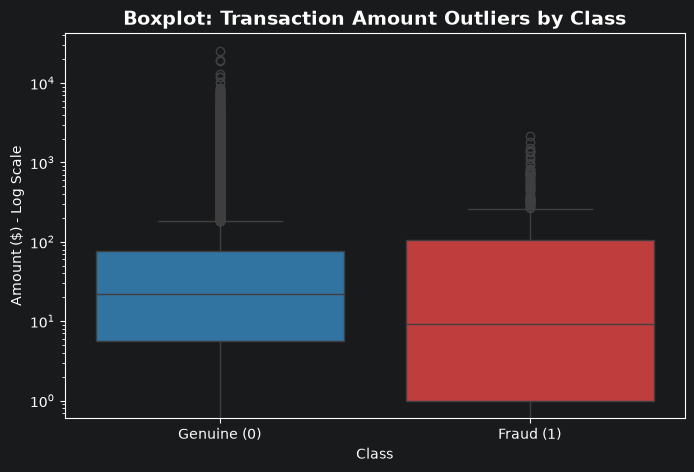

In [18]:
# 3. Boxplot (Outlier Detection in Amount)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df, hue='Class', palette=['#1f77b4', '#d62728'], legend=False)
plt.title("Boxplot: Transaction Amount Outliers by Class", fontsize=14, fontweight='bold')
plt.yscale('log') # Log scale helps visualize the massive outliers
plt.xticks([0, 1], ['Genuine (0)', 'Fraud (1)'])
plt.ylabel("Amount ($) - Log Scale")
plt.savefig("poster_3_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Time vs Amount (Scatter Plot)
Plotting a sample of genuine transactions alongside all fraudulent transactions to observe any patterns over time.

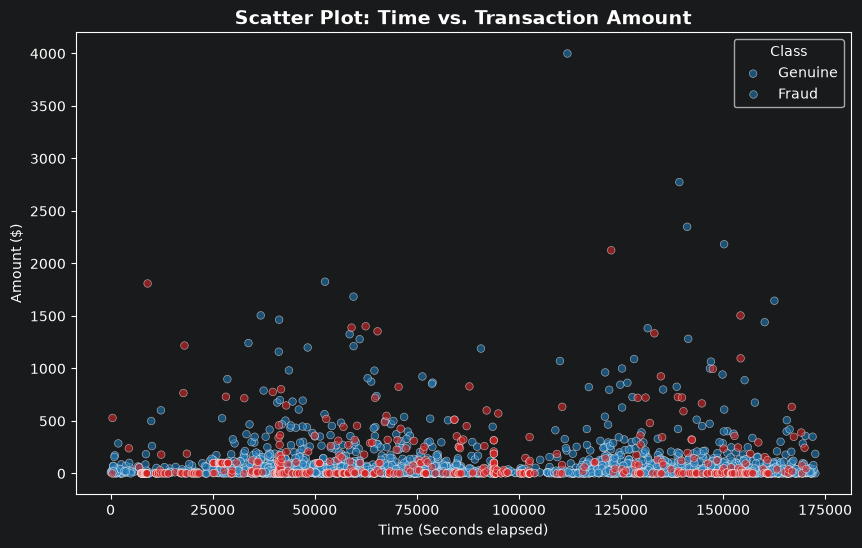

In [19]:
# 4. Scatter Plot (Time vs Amount)
# We take a random sample of genuine transactions so the plot isn't a solid block of color,
# but we plot ALL fraud transactions to make them pop out.
genuine_sample = df[df['Class'] == 0].sample(2000, random_state=42)
fraud_all = df[df['Class'] == 1]
scatter_data = pd.concat([genuine_sample, fraud_all])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Time',
    y='Amount',
    data=scatter_data,
    hue='Class',
    palette=['#1f77b4', '#d62728'], # Standard Blue and Red
    alpha=0.6,
    s=30 # 's' is the size of the dots
)
plt.title("Scatter Plot: Time vs. Transaction Amount", fontsize=14, fontweight='bold')
plt.xlabel("Time (Seconds elapsed)")
plt.ylabel("Amount ($)")
plt.legend(title='Class', labels=['Genuine', 'Fraud'])
plt.savefig("poster_4_scatterplot.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. Feature Correlation (Heatmap)
Visualizing the correlation matrix of the top 12 features selected during the feature selection phase, along with the target class.

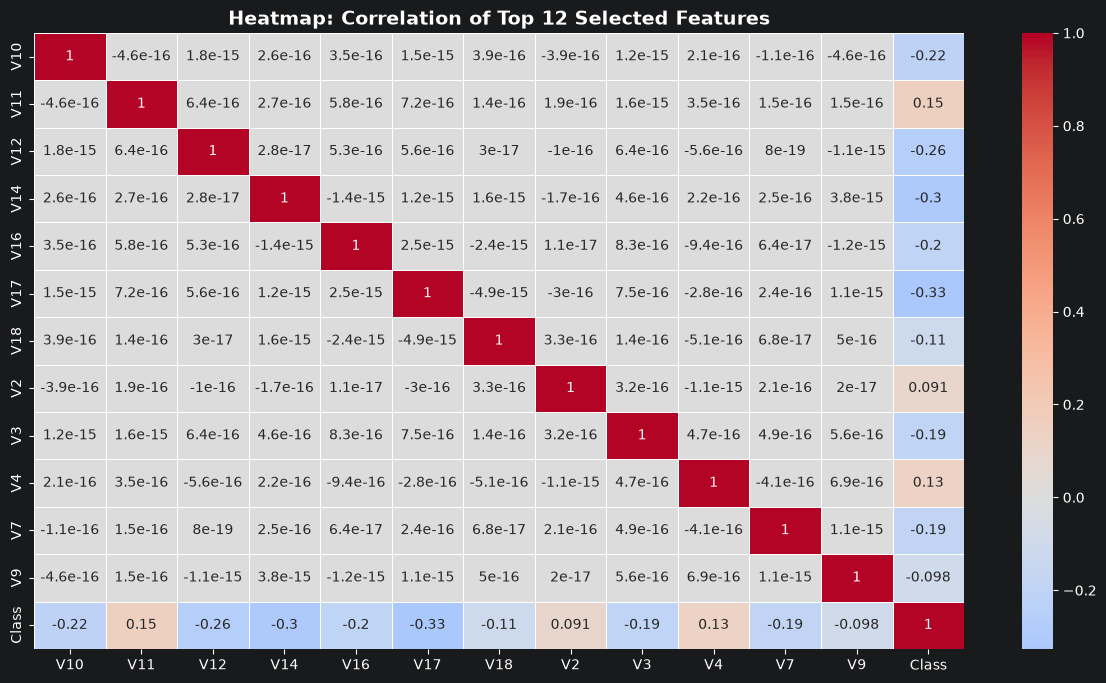

In [20]:
# 5. Heatmap (Correlation of Top 12 Features + Target)
# These are the 12 features you locked in during your feature selection!
final_features = ['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V2', 'V3', 'V4', 'V7', 'V9', 'Class']
plt.figure(figsize=(15, 8))
corr_matrix = df[final_features].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 10}, linewidths=0.5)
plt.title("Heatmap: Correlation of Top 12 Selected Features", fontsize=14, fontweight='bold')
plt.savefig("poster_5_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()